# Notebook 4 — Constrained Tuning and Ensemble Analysis

This notebook:
- reloads the processed claim-level tables and the split files from Notebook 3
- rebuilds the same train-only preprocessing logic used in the baseline benchmark
- performs **constrained hyperparameter tuning** on the validation benchmark only
- selects best configurations by validation **average precision** with recall@k as a tie-breaker
- evaluates the tuned models on the test benchmark
- builds simple ensemble strategies:
  - rank aggregation
  - majority voting
  - set overlap diagnostics
- saves tuning tables, tuned-model metrics, ensemble metrics, and figures for later notebooks

## Design notes
- Notebook 3 remains the **baseline benchmark** notebook. Do not move tuning back into Notebook 3.
- Tuning is intentionally limited and literature-aligned, not exhaustive.
- Ensemble methods are interpreted as **prioritization / robustness tools**, not truth validators.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Cell 1 - Load libraries and project paths
import json
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM

THESIS_ROOT = Path('/content/drive/MyDrive/NyanThesisAnomaly')

with open(THESIS_ROOT / 'project_paths.json', 'r', encoding='utf-8') as f:
    PROJECT_PATHS = json.load(f)

DATA_PROCESSED_DIR = Path(PROJECT_PATHS['DATA_PROCESSED_DIR'])
TABLES_DIR = Path(PROJECT_PATHS['TABLES_DIR'])
FIGURES_DIR = Path(PROJECT_PATHS['FIGURES_DIR'])
NOTEBOOK_EXPORTS_DIR = Path(PROJECT_PATHS['NOTEBOOK_EXPORTS_DIR'])
PHASE1_DIR = Path(PROJECT_PATHS['PHASE1_DIR'])
PHASE2_DIR = Path(PROJECT_PATHS['PHASE2_DIR'])

ANALYTICAL_PATH = DATA_PROCESSED_DIR / 'claims_analytical_table_v1.parquet'
MODEL_FEATURES_PATH = DATA_PROCESSED_DIR / 'claims_model_features_v1.parquet'

TRAIN_KEYS_PATH = PHASE1_DIR / '03_train_claim_keys.csv'
VAL_KEYS_PATH = PHASE1_DIR / '03_validation_claim_keys.csv'
TEST_KEYS_PATH = PHASE1_DIR / '03_test_claim_keys.csv'

RANDOM_STATE = 42

print('Analytical path:', ANALYTICAL_PATH)
print('Model features path:', MODEL_FEATURES_PATH)
print('Phase 1 dir:', PHASE1_DIR)
print('Phase 2 dir:', PHASE2_DIR)


Analytical path: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet
Model features path: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet
Phase 1 dir: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase1_benchmark
Phase 2 dir: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning


In [3]:
#Cell 2 - Load processed data and split files
claims_analytical = pd.read_parquet(ANALYTICAL_PATH)
model_features = pd.read_parquet(MODEL_FEATURES_PATH)

train_keys = pd.read_csv(TRAIN_KEYS_PATH)['CLAIM_KEY'].astype(str)
val_keys = pd.read_csv(VAL_KEYS_PATH)['CLAIM_KEY'].astype(str)
test_keys = pd.read_csv(TEST_KEYS_PATH)['CLAIM_KEY'].astype(str)

print('Analytical shape:', claims_analytical.shape)
print('Model feature shape:', model_features.shape)
print('Train/Val/Test keys:', len(train_keys), len(val_keys), len(test_keys))


Analytical shape: (175005, 103)
Model feature shape: (175005, 23)
Train/Val/Test keys: 122503 26251 26251


In [4]:
#Cell 3 - Rebuild the merged benchmark table and split-specific frames
merged = model_features.merge(
    claims_analytical[['CLAIM_KEY', 'primary_diag_code', 'primary_proc_code', 'primary_hcpcs_code']],
    on='CLAIM_KEY',
    how='left',
    validate='one_to_one'
)

merged['CLAIM_KEY'] = merged['CLAIM_KEY'].astype(str)

train_df = merged[merged['CLAIM_KEY'].isin(train_keys)].copy()
val_df = merged[merged['CLAIM_KEY'].isin(val_keys)].copy()
test_df = merged[merged['CLAIM_KEY'].isin(test_keys)].copy()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n_rows': [len(train_df), len(val_df), len(test_df)]
})

display(split_summary)


,split,n_rows
0,train,122503
1,validation,26251
2,test,26251


In [5]:
#Cell 4 - Fit train-only rarity maps and add rarity features
def build_frequency_map(series):
    clean = series.dropna().astype(str)
    if clean.empty:
        return {}
    return clean.value_counts(normalize=True).to_dict()

diag_freq_map = build_frequency_map(train_df['primary_diag_code'])
proc_freq_map = build_frequency_map(train_df['primary_proc_code'])
hcpcs_freq_map = build_frequency_map(train_df['primary_hcpcs_code'])

pair_series = (
    train_df['primary_diag_code'].astype('string').fillna('MISSING')
    + '||' +
    train_df['primary_hcpcs_code'].astype('string').fillna('MISSING')
)
pair_freq_map = pair_series.value_counts(normalize=True).to_dict()

def add_rarity_features(frame):
    out = frame.copy()

    out['primary_diag_freq_train'] = out['primary_diag_code'].astype('string').map(diag_freq_map).fillna(0.0)
    out['primary_proc_freq_train'] = out['primary_proc_code'].astype('string').map(proc_freq_map).fillna(0.0)
    out['primary_hcpcs_freq_train'] = out['primary_hcpcs_code'].astype('string').map(hcpcs_freq_map).fillna(0.0)

    pair_key = (
        out['primary_diag_code'].astype('string').fillna('MISSING')
        + '||' +
        out['primary_hcpcs_code'].astype('string').fillna('MISSING')
    )
    out['diag_hcpcs_pair_freq_train'] = pair_key.map(pair_freq_map).fillna(0.0)

    out['rare_primary_diag_flag'] = (out['primary_diag_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_proc_flag'] = (out['primary_proc_freq_train'] <= 0.001).astype('int8')
    out['rare_primary_hcpcs_flag'] = (out['primary_hcpcs_freq_train'] <= 0.001).astype('int8')
    out['rare_diag_hcpcs_pair_flag'] = (out['diag_hcpcs_pair_freq_train'] <= 0.0005).astype('int8')

    return out

train_df = add_rarity_features(train_df)
val_df = add_rarity_features(val_df)
test_df = add_rarity_features(test_df)

display(train_df[[
    'primary_diag_freq_train',
    'primary_proc_freq_train',
    'primary_hcpcs_freq_train',
    'diag_hcpcs_pair_freq_train'
]].head())


,primary_diag_freq_train,primary_proc_freq_train,primary_hcpcs_freq_train,diag_hcpcs_pair_freq_train
1,0.000498,0.0,0.000259,0.000008
2,0.000098,0.0,0.029033,0.000008
3,0.000090,0.0,0.000000,0.000033
5,0.000033,0.0,0.004035,0.000008
6,0.000073,0.0,0.036885,0.000008


In [6]:
#Cell 5 - Add cyclical time features and define final feature columns
def add_cyclical_time_features(frame):
    out = frame.copy()
    out['claim_from_month_sin'] = np.sin(2 * np.pi * out['claim_from_month'].fillna(0) / 12)
    out['claim_from_month_cos'] = np.cos(2 * np.pi * out['claim_from_month'].fillna(0) / 12)
    out['claim_from_dayofweek_sin'] = np.sin(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)
    out['claim_from_dayofweek_cos'] = np.cos(2 * np.pi * out['claim_from_dayofweek'].fillna(0) / 7)
    return out

train_df = add_cyclical_time_features(train_df)
val_df = add_cyclical_time_features(val_df)
test_df = add_cyclical_time_features(test_df)

FINAL_FEATURE_COLS = [
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'total_beneficiary_liability',
    'claim_duration_days',
    'claim_from_month',
    'claim_from_dayofweek',
    'claim_from_day',
    'is_weekend_claim',
    'is_same_day_claim',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'has_admitting_diag',
    'has_any_diag',
    'has_any_proc',
    'has_any_hcpcs',
    'zero_payment_flag',
    'log_clm_pmt_amt',
    'log_primary_payer_amt',
    'log_total_bene_liability',
    'high_cost_flag_p95',
    'extreme_cost_flag_p99',
    'primary_diag_freq_train',
    'primary_proc_freq_train',
    'primary_hcpcs_freq_train',
    'diag_hcpcs_pair_freq_train',
    'rare_primary_diag_flag',
    'rare_primary_proc_flag',
    'rare_primary_hcpcs_flag',
    'rare_diag_hcpcs_pair_flag',
    'claim_from_month_sin',
    'claim_from_month_cos',
    'claim_from_dayofweek_sin',
    'claim_from_dayofweek_cos',
]

print('Final feature count:', len(FINAL_FEATURE_COLS))


Final feature count: 34


In [7]:
#Cell 6 - Fit train-only imputation and robust scaling
train_medians = train_df[FINAL_FEATURE_COLS].median(numeric_only=True)

def prepare_numeric_features(frame, scaler=None, fit_scaler=False):
    X = frame[FINAL_FEATURE_COLS].copy().fillna(train_medians)

    if fit_scaler:
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = scaler.transform(X)

    X_scaled = pd.DataFrame(X_scaled, columns=FINAL_FEATURE_COLS, index=frame.index)
    return X, X_scaled, scaler

X_train_raw, X_train_scaled, scaler = prepare_numeric_features(train_df, fit_scaler=True)
X_val_raw, X_val_scaled, _ = prepare_numeric_features(val_df, scaler=scaler, fit_scaler=False)
X_test_raw, X_test_scaled, _ = prepare_numeric_features(test_df, scaler=scaler, fit_scaler=False)

MAX_TRAIN_TUNING = 30000
if len(X_train_scaled) > MAX_TRAIN_TUNING:
    tuning_idx = train_df.sample(n=MAX_TRAIN_TUNING, random_state=RANDOM_STATE).index
else:
    tuning_idx = train_df.index

train_tuning_df = train_df.loc[tuning_idx].copy()
X_train_tuning = X_train_scaled.loc[tuning_idx].copy()

print('Training rows used for tuning:', len(X_train_tuning))


Training rows used for tuning: 30000


In [8]:
#Cell 7 - Reuse the controlled anomaly injection functions
def choose_with_replacement(base_df, n, seed):
    rng = np.random.default_rng(seed)
    idx = rng.choice(base_df.index.to_numpy(), size=n, replace=True)
    return base_df.loc[idx].copy().reset_index(drop=True)

def inject_monetary_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)
    multiplier = rng.uniform(2.0, 5.0, size=n)

    sample['CLM_PMT_AMT'] = sample['CLM_PMT_AMT'].fillna(0) * multiplier
    sample['NCH_PRMRY_PYR_CLM_PD_AMT'] = sample['NCH_PRMRY_PYR_CLM_PD_AMT'].fillna(0) * rng.uniform(1.5, 4.0, size=n)
    sample['total_beneficiary_liability'] = sample['total_beneficiary_liability'].fillna(0) * rng.uniform(1.5, 4.0, size=n)

    sample['log_clm_pmt_amt'] = np.log1p(np.clip(sample['CLM_PMT_AMT'], 0, None))
    sample['log_primary_payer_amt'] = np.log1p(np.clip(sample['NCH_PRMRY_PYR_CLM_PD_AMT'], 0, None))
    sample['log_total_bene_liability'] = np.log1p(np.clip(sample['total_beneficiary_liability'], 0, None))

    sample['high_cost_flag_p95'] = 1
    sample['extreme_cost_flag_p99'] = 1
    return sample

def inject_temporal_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)

    max_duration = max(float(train_df['claim_duration_days'].quantile(0.99)), 7.0)
    sample['claim_duration_days'] = rng.integers(int(max_duration), int(max_duration * 2) + 1, size=n)
    sample['claim_from_dayofweek'] = rng.choice([5, 6], size=n)
    sample['is_weekend_claim'] = 1
    sample['is_same_day_claim'] = 0
    sample['claim_from_day'] = rng.integers(1, 29, size=n)

    sample['claim_from_dayofweek_sin'] = np.sin(2 * np.pi * sample['claim_from_dayofweek'] / 7)
    sample['claim_from_dayofweek_cos'] = np.cos(2 * np.pi * sample['claim_from_dayofweek'] / 7)
    return sample

def inject_coding_utilization_anomalies(base_df, n, seed):
    rng = np.random.default_rng(seed)
    sample = choose_with_replacement(base_df, n, seed)

    q_diag = max(int(train_df['diag_code_count'].quantile(0.99)), 5)
    q_proc = max(int(train_df['proc_code_count'].quantile(0.99)), 3)
    q_hcpcs = max(int(train_df['hcpcs_code_count'].quantile(0.99)), 8)

    sample['diag_code_count'] = rng.integers(max(3, q_diag - 2), q_diag + 3, size=n)
    sample['proc_code_count'] = rng.integers(max(2, q_proc - 1), q_proc + 2, size=n)
    sample['hcpcs_code_count'] = rng.integers(max(5, q_hcpcs - 3), q_hcpcs + 4, size=n)

    sample['has_any_diag'] = 1
    sample['has_any_proc'] = 1
    sample['has_any_hcpcs'] = 1
    sample['has_admitting_diag'] = 1

    sample['primary_diag_freq_train'] = 0.0
    sample['primary_proc_freq_train'] = 0.0
    sample['primary_hcpcs_freq_train'] = 0.0
    sample['diag_hcpcs_pair_freq_train'] = 0.0

    sample['rare_primary_diag_flag'] = 1
    sample['rare_primary_proc_flag'] = 1
    sample['rare_primary_hcpcs_flag'] = 1
    sample['rare_diag_hcpcs_pair_flag'] = 1
    return sample

def inject_mixed_anomalies(base_df, rate, seed):
    n_anomalies = max(1, int(round(len(base_df) * rate)))
    family_names = ['monetary', 'temporal', 'coding_utilization']
    family_sizes = [n_anomalies // 3, n_anomalies // 3, n_anomalies - 2 * (n_anomalies // 3)]

    injected_parts = []
    family_generators = {
        'monetary': inject_monetary_anomalies,
        'temporal': inject_temporal_anomalies,
        'coding_utilization': inject_coding_utilization_anomalies,
    }

    family_seed_offset = 0
    for family, size in zip(family_names, family_sizes):
        if size <= 0:
            continue
        part = family_generators[family](base_df, size, seed + family_seed_offset)
        part['is_injected_anomaly'] = 1
        part['injected_family'] = family
        part['source_claim_key'] = part['CLAIM_KEY']
        part['CLAIM_KEY'] = part['CLAIM_KEY'].astype(str) + f'_INJECTED_{family.upper()}_' + np.arange(len(part)).astype(str)
        injected_parts.append(part)
        family_seed_offset += 1000

    anomalies_df = pd.concat(injected_parts, ignore_index=True)
    normal_df = base_df.copy()
    normal_df['is_injected_anomaly'] = 0
    normal_df['injected_family'] = 'normal'
    normal_df['source_claim_key'] = normal_df['CLAIM_KEY']

    combined = pd.concat([normal_df, anomalies_df], ignore_index=True)
    return combined


In [9]:
#Cell 8 - Define evaluation helpers and constrained tuning grids
RATES = [0.01, 0.03, 0.05]

TUNING_GRIDS = {
    'iforest': [
        {'n_estimators': 100, 'max_samples': 'auto'},
        {'n_estimators': 200, 'max_samples': 'auto'},
        {'n_estimators': 300, 'max_samples': 'auto'},
        {'n_estimators': 200, 'max_samples': 0.5},
        {'n_estimators': 200, 'max_samples': 0.8},
    ],
    'lof': [
        {'n_neighbors': 15},
        {'n_neighbors': 25},
        {'n_neighbors': 35},
        {'n_neighbors': 50},
    ],
    'ocsvm': [
        {'nu': 0.01, 'gamma': 'scale'},
        {'nu': 0.03, 'gamma': 'scale'},
        {'nu': 0.05, 'gamma': 'scale'},
        {'nu': 0.03, 'gamma': 0.1},
        {'nu': 0.03, 'gamma': 1.0},
    ],
}

def build_model(model_name, rate, params):
    if model_name == 'iforest':
        return IsolationForest(
            n_estimators=params['n_estimators'],
            max_samples=params['max_samples'],
            contamination=rate,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_name == 'lof':
        return LocalOutlierFactor(
            n_neighbors=params['n_neighbors'],
            contamination=rate,
            novelty=True,
        )
    if model_name == 'ocsvm':
        return OneClassSVM(
            kernel='rbf',
            nu=params['nu'],
            gamma=params['gamma'],
        )
    raise ValueError(f'Unknown model name: {model_name}')

def get_anomaly_scores(model, X):
    if hasattr(model, 'score_samples'):
        scores = -model.score_samples(X)
    else:
        scores = -model.decision_function(X)
    return np.asarray(scores)

def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    top_idx = order[:k]
    return float(np.mean(y_true[top_idx]))

def recall_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    top_idx = order[:k]
    positives = np.sum(y_true)
    if positives == 0:
        return np.nan
    return float(np.sum(y_true[top_idx]) / positives)

def family_recall_at_k(eval_df, scores, k):
    anomaly_rows = eval_df[eval_df['is_injected_anomaly'] == 1].copy()
    if anomaly_rows.empty:
        return {}

    order = np.argsort(scores)[::-1]
    top_keys = set(eval_df.iloc[order[:k]]['CLAIM_KEY'].astype(str))

    recalls = {}
    for family in sorted(anomaly_rows['injected_family'].unique()):
        fam = anomaly_rows[anomaly_rows['injected_family'] == family]
        recalls[family] = float(np.mean(fam['CLAIM_KEY'].astype(str).isin(top_keys)))
    return recalls

def percentile_rank_scores(scores):
    s = pd.Series(scores)
    return s.rank(method='average', pct=True).to_numpy()


In [10]:
#Cell 9 - Create reproducible validation and test benchmark sets for each anomaly-rate setting
validation_eval_sets = {}
test_eval_sets = {}

for rate in RATES:
    validation_eval_sets[rate] = inject_mixed_anomalies(val_df, rate=rate, seed=RANDOM_STATE + int(rate * 10000))
    test_eval_sets[rate] = inject_mixed_anomalies(test_df, rate=rate, seed=RANDOM_STATE + int(rate * 10000))

validation_set_summary = []
for rate in RATES:
    validation_set_summary.append({
        'assumed_rate': rate,
        'validation_rows': len(validation_eval_sets[rate]),
        'validation_injected': int(validation_eval_sets[rate]['is_injected_anomaly'].sum()),
        'test_rows': len(test_eval_sets[rate]),
        'test_injected': int(test_eval_sets[rate]['is_injected_anomaly'].sum()),
    })

validation_set_summary = pd.DataFrame(validation_set_summary)
display(validation_set_summary)

validation_set_summary.to_csv(PHASE2_DIR / '04_eval_set_summary.csv', index=False)


,assumed_rate,validation_rows,validation_injected,test_rows,test_injected
0,0.01,26514,263,26514,263
1,0.03,27039,788,27039,788
2,0.05,27564,1313,27564,1313


In [11]:
#Cell 10 - Run constrained tuning on the validation benchmark
tuning_results = []

for rate in RATES:
    eval_df = validation_eval_sets[rate].copy()
    X_eval_raw = eval_df[FINAL_FEATURE_COLS].copy().fillna(train_medians)
    X_eval_scaled = scaler.transform(X_eval_raw)
    y_true = eval_df['is_injected_anomaly'].to_numpy()
    k = int(np.sum(y_true))

    print(f'Tuning on validation benchmark for assumed rate {rate:.0%}')

    for model_name, param_list in TUNING_GRIDS.items():
        for param_idx, params in enumerate(param_list, start=1):
            model = build_model(model_name, rate, params)
            model.fit(X_train_tuning)
            scores = get_anomaly_scores(model, X_eval_scaled)

            row = {
                'assumed_rate': rate,
                'model': model_name,
                'param_index': param_idx,
                'params_json': json.dumps(params, sort_keys=True),
                'average_precision': float(average_precision_score(y_true, scores)),
                'roc_auc': float(roc_auc_score(y_true, scores)),
                'precision_at_k': precision_at_k(y_true, scores, k),
                'recall_at_k': recall_at_k(y_true, scores, k),
            }
            tuning_results.append(row)

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df.sort_values(['assumed_rate', 'model', 'average_precision'], ascending=[True, True, False]).head(20))


Tuning on validation benchmark for assumed rate 1%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

Tuning on validation benchmark for assumed rate 3%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

Tuning on validation benchmark for assumed rate 5%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

,assumed_rate,model,param_index,params_json,average_precision,roc_auc,precision_at_k,recall_at_k
4,0.01,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.124020,0.931044,0.174905,0.174905
3,0.01,iforest,4,"{""max_samples"": 0.5, ""n_estimators"": 200}",0.115496,0.931303,0.152091,0.152091
1,0.01,iforest,2,"{""max_samples"": ""auto"", ""n_estimators"": 200}",0.043427,0.893881,0.015209,0.015209
2,0.01,iforest,3,"{""max_samples"": ""auto"", ""n_estimators"": 300}",0.042087,0.890685,0.015209,0.015209
0,0.01,iforest,1,"{""max_samples"": ""auto"", ""n_estimators"": 100}",0.041069,0.886690,0.015209,0.015209
5,0.01,lof,1,"{""n_neighbors"": 15}",0.394098,0.957103,0.425856,0.425856
6,0.01,lof,2,"{""n_neighbors"": 25}",0.354769,0.953347,0.418251,0.418251
7,0.01,lof,3,"{""n_neighbors"": 35}",0.339973,0.947549,0.403042,0.403042
8,0.01,lof,4,"{""n_neighbors"": 50}",0.299313,0.937783,0.357414,0.357414
12,0.01,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.390581,0.967801,0.501901,0.501901


In [12]:
#Cell 11 - Select best validation configuration per model and anomaly-rate setting
best_configs = (
    tuning_results_df
    .sort_values(['assumed_rate', 'model', 'average_precision', 'recall_at_k'], ascending=[True, True, False, False])
    .groupby(['assumed_rate', 'model'], as_index=False)
    .first()
)

display(best_configs)

tuning_results_path = PHASE2_DIR / '04_tuning_results.csv'
best_configs_path = PHASE2_DIR / '04_best_configs.csv'

tuning_results_df.to_csv(tuning_results_path, index=False)
best_configs.to_csv(best_configs_path, index=False)

print('Saved tuning results to:', tuning_results_path)
print('Saved best config table to:', best_configs_path)


,assumed_rate,model,param_index,params_json,average_precision,roc_auc,precision_at_k,recall_at_k
0,0.01,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.124020,0.931044,0.174905,0.174905
1,0.01,lof,1,"{""n_neighbors"": 15}",0.394098,0.957103,0.425856,0.425856
2,0.01,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.390581,0.967801,0.501901,0.501901
3,0.03,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.300458,0.932898,0.404822,0.404822
4,0.03,lof,1,"{""n_neighbors"": 15}",0.630818,0.951411,0.645939,0.645939
5,0.03,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.624320,0.969619,0.662437,0.662437
6,0.05,iforest,5,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.433593,0.937745,0.505712,0.505712
7,0.05,lof,1,"{""n_neighbors"": 15}",0.720943,0.957407,0.712871,0.712871
8,0.05,ocsvm,4,"{""gamma"": 0.1, ""nu"": 0.03}",0.703244,0.967309,0.674029,0.674029


Saved tuning results to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_tuning_results.csv
Saved best config table to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_best_configs.csv


In [13]:
#Cell 12 - Evaluate tuned models on validation and test benchmarks and save per-case scores
tuned_metrics = []
tuned_scores = []

for rate in RATES:
    rate_best = best_configs[best_configs['assumed_rate'] == rate].copy()

    for _, cfg in rate_best.iterrows():
        model_name = cfg['model']
        params = json.loads(cfg['params_json'])
        model = build_model(model_name, rate, params)
        model.fit(X_train_tuning)

        for split_name, eval_sets in [('validation', validation_eval_sets), ('test', test_eval_sets)]:
            eval_df = eval_sets[rate].copy()
            X_eval_raw = eval_df[FINAL_FEATURE_COLS].copy().fillna(train_medians)
            X_eval_scaled = scaler.transform(X_eval_raw)
            y_true = eval_df['is_injected_anomaly'].to_numpy()
            k = int(np.sum(y_true))

            scores = get_anomaly_scores(model, X_eval_scaled)

            metric_row = {
                'split': split_name,
                'assumed_rate': rate,
                'model': model_name,
                'params_json': json.dumps(params, sort_keys=True),
                'average_precision': float(average_precision_score(y_true, scores)),
                'roc_auc': float(roc_auc_score(y_true, scores)),
                'precision_at_k': precision_at_k(y_true, scores, k),
                'recall_at_k': recall_at_k(y_true, scores, k),
            }
            family_recalls = family_recall_at_k(eval_df, scores, k)
            for family_name, family_value in family_recalls.items():
                metric_row[f'recall_at_k__{family_name}'] = family_value

            tuned_metrics.append(metric_row)

            score_df = pd.DataFrame({
                'split': split_name,
                'assumed_rate': rate,
                'model': model_name,
                'params_json': json.dumps(params, sort_keys=True),
                'CLAIM_KEY': eval_df['CLAIM_KEY'].astype(str),
                'source_claim_key': eval_df['source_claim_key'].astype(str),
                'is_injected_anomaly': y_true,
                'injected_family': eval_df['injected_family'].astype(str),
                'anomaly_score': scores,
            })
            tuned_scores.append(score_df)

tuned_metrics_df = pd.DataFrame(tuned_metrics)
tuned_scores_df = pd.concat(tuned_scores, ignore_index=True)

display(tuned_metrics_df.sort_values(['split', 'assumed_rate', 'average_precision'], ascending=[True, True, False]).head(30))

tuned_metrics_df.to_csv(PHASE2_DIR / '04_tuned_model_metrics.csv', index=False)
tuned_scores_df.to_parquet(PHASE2_DIR / '04_tuned_model_scores.parquet', index=False)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skl

,split,assumed_rate,model,params_json,average_precision,roc_auc,precision_at_k,recall_at_k,recall_at_k__coding_utilization,recall_at_k__monetary,recall_at_k__temporal
5,test,0.01,ocsvm,"{""gamma"": 0.1, ""nu"": 0.03}",0.409217,0.964142,0.486692,0.486692,0.539326,0.080460,0.839080
3,test,0.01,lof,"{""n_neighbors"": 15}",0.402314,0.947951,0.437262,0.437262,0.348315,0.183908,0.781609
1,test,0.01,iforest,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.163585,0.941651,0.201521,0.201521,0.382022,0.103448,0.114943
11,test,0.03,ocsvm,"{""gamma"": 0.1, ""nu"": 0.03}",0.626733,0.969437,0.652284,0.652284,0.954545,0.133588,0.866412
9,test,0.03,lof,"{""n_neighbors"": 15}",0.621433,0.953300,0.620558,0.620558,0.704545,0.328244,0.828244
7,test,0.03,iforest,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.316926,0.932966,0.403553,0.403553,0.863636,0.263359,0.080153
15,test,0.05,lof,"{""n_neighbors"": 15}",0.706188,0.946656,0.702209,0.702209,0.835991,0.421053,0.848970
17,test,0.05,ocsvm,"{""gamma"": 0.1, ""nu"": 0.03}",0.694448,0.964562,0.667936,0.667936,0.995444,0.139588,0.867277
13,test,0.05,iforest,"{""max_samples"": 0.8, ""n_estimators"": 200}",0.417754,0.932466,0.487433,0.487433,0.993166,0.308924,0.157895
2,validation,0.01,lof,"{""n_neighbors"": 15}",0.394098,0.957103,0.425856,0.425856,0.359551,0.126437,0.793103


In [14]:
#Cell 13 - Build rank-aggregation and majority-vote ensembles from tuned model scores
ensemble_metrics = []
ensemble_scores_all = []
overlap_rows = []

for split_name in ['validation', 'test']:
    for rate in RATES:
        split_scores = tuned_scores_df[
            (tuned_scores_df['split'] == split_name) &
            (tuned_scores_df['assumed_rate'] == rate)
        ].copy()

        pivot = split_scores.pivot_table(
            index=['CLAIM_KEY', 'source_claim_key', 'is_injected_anomaly', 'injected_family'],
            columns='model',
            values='anomaly_score'
        ).reset_index()

        model_cols = [c for c in pivot.columns if c in ['iforest', 'lof', 'ocsvm']]
        for c in model_cols:
            pivot[f'{c}_pct_rank'] = percentile_rank_scores(pivot[c].to_numpy())

        k = int(pivot['is_injected_anomaly'].sum())

        pivot['ensemble_rank_mean'] = pivot[[f'{c}_pct_rank' for c in model_cols]].mean(axis=1)

        top_flags = []
        for c in model_cols:
            threshold = np.quantile(pivot[c], 1 - rate)
            flag = (pivot[c] >= threshold).astype(int)
            pivot[f'{c}_topflag'] = flag
            top_flags.append(f'{c}_topflag')

        pivot['ensemble_vote_count'] = pivot[top_flags].sum(axis=1)
        pivot['ensemble_majority_vote_score'] = pivot['ensemble_vote_count'] / len(model_cols)

        y_true = pivot['is_injected_anomaly'].to_numpy()
        rank_scores = pivot['ensemble_rank_mean'].to_numpy()
        vote_scores = pivot['ensemble_majority_vote_score'].to_numpy()

        ensemble_metrics.append({
            'split': split_name,
            'assumed_rate': rate,
            'ensemble_method': 'rank_aggregation',
            'average_precision': float(average_precision_score(y_true, rank_scores)),
            'roc_auc': float(roc_auc_score(y_true, rank_scores)),
            'precision_at_k': precision_at_k(y_true, rank_scores, k),
            'recall_at_k': recall_at_k(y_true, rank_scores, k),
        })

        ensemble_metrics.append({
            'split': split_name,
            'assumed_rate': rate,
            'ensemble_method': 'majority_vote',
            'average_precision': float(average_precision_score(y_true, vote_scores)),
            'roc_auc': float(roc_auc_score(y_true, vote_scores)),
            'precision_at_k': precision_at_k(y_true, vote_scores, k),
            'recall_at_k': recall_at_k(y_true, vote_scores, k),
        })

        top_sets = {}
        for c in model_cols:
            top_idx = np.argsort(pivot[c].to_numpy())[::-1][:k]
            top_sets[c] = set(pivot.iloc[top_idx]['CLAIM_KEY'].astype(str))

        for a, b in combinations(model_cols, 2):
            inter = len(top_sets[a].intersection(top_sets[b]))
            union = len(top_sets[a].union(top_sets[b]))
            jaccard = inter / union if union else np.nan

            overlap_rows.append({
                'split': split_name,
                'assumed_rate': rate,
                'model_a': a,
                'model_b': b,
                'top_k': k,
                'intersection_count': inter,
                'union_count': union,
                'jaccard_top_k': jaccard,
            })

        ensemble_scores = pivot[[
            'CLAIM_KEY', 'source_claim_key', 'is_injected_anomaly', 'injected_family'
        ] + model_cols + [f'{c}_pct_rank' for c in model_cols] + ['ensemble_rank_mean', 'ensemble_vote_count', 'ensemble_majority_vote_score']].copy()
        ensemble_scores['split'] = split_name
        ensemble_scores['assumed_rate'] = rate
        ensemble_scores_all.append(ensemble_scores)

ensemble_metrics_df = pd.DataFrame(ensemble_metrics)
overlap_df = pd.DataFrame(overlap_rows)
ensemble_scores_df = pd.concat(ensemble_scores_all, ignore_index=True)

display(ensemble_metrics_df.sort_values(['split', 'assumed_rate', 'average_precision'], ascending=[True, True, False]))


,split,assumed_rate,ensemble_method,average_precision,roc_auc,precision_at_k,recall_at_k
6,test,0.01,rank_aggregation,0.388239,0.977905,0.460076,0.460076
7,test,0.01,majority_vote,0.303023,0.782087,0.479087,0.479087
8,test,0.03,rank_aggregation,0.608342,0.979530,0.578680,0.578680
9,test,0.03,majority_vote,0.552589,0.888127,0.659898,0.659898
10,test,0.05,rank_aggregation,0.705828,0.976528,0.644326,0.644326
11,test,0.05,majority_vote,0.624661,0.910646,0.690023,0.690023
0,validation,0.01,rank_aggregation,0.341289,0.979150,0.418251,0.418251
1,validation,0.01,majority_vote,0.298960,0.793196,0.448669,0.448669
2,validation,0.03,rank_aggregation,0.602488,0.978374,0.568528,0.568528
3,validation,0.03,majority_vote,0.560374,0.890429,0.662437,0.662437


In [15]:
#Cell 14 - Save ensemble and overlap outputs
ensemble_metrics_path = PHASE2_DIR / '04_ensemble_metrics.csv'
ensemble_scores_path = PHASE2_DIR / '04_ensemble_scores.parquet'
overlap_path = PHASE2_DIR / '04_model_overlap_diagnostics.csv'

ensemble_metrics_df.to_csv(ensemble_metrics_path, index=False)
ensemble_scores_df.to_parquet(ensemble_scores_path, index=False)
overlap_df.to_csv(overlap_path, index=False)

print('Saved ensemble metrics to:', ensemble_metrics_path)
print('Saved ensemble scores to:', ensemble_scores_path)
print('Saved overlap diagnostics to:', overlap_path)


Saved ensemble metrics to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_ensemble_metrics.csv
Saved ensemble scores to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_ensemble_scores.parquet
Saved overlap diagnostics to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_model_overlap_diagnostics.csv


In [16]:
#Cell 15 - Build comparison tables between tuned single models and ensembles
single_summary = tuned_metrics_df[['split', 'assumed_rate', 'model', 'average_precision', 'precision_at_k', 'recall_at_k']].copy()
single_summary['method'] = single_summary['model']

ensemble_summary = ensemble_metrics_df[['split', 'assumed_rate', 'ensemble_method', 'average_precision', 'precision_at_k', 'recall_at_k']].copy()
ensemble_summary = ensemble_summary.rename(columns={'ensemble_method': 'method'})

comparison_df = pd.concat([
    single_summary[['split', 'assumed_rate', 'method', 'average_precision', 'precision_at_k', 'recall_at_k']],
    ensemble_summary[['split', 'assumed_rate', 'method', 'average_precision', 'precision_at_k', 'recall_at_k']],
], ignore_index=True)

comparison_path = TABLES_DIR / '04_tuned_and_ensemble_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df.sort_values(['split', 'assumed_rate', 'average_precision'], ascending=[True, True, False]))
print('Saved comparison table to:', comparison_path)


,split,assumed_rate,method,average_precision,precision_at_k,recall_at_k
5,test,0.01,ocsvm,0.409217,0.486692,0.486692
3,test,0.01,lof,0.402314,0.437262,0.437262
24,test,0.01,rank_aggregation,0.388239,0.460076,0.460076
25,test,0.01,majority_vote,0.303023,0.479087,0.479087
1,test,0.01,iforest,0.163585,0.201521,0.201521
11,test,0.03,ocsvm,0.626733,0.652284,0.652284
9,test,0.03,lof,0.621433,0.620558,0.620558
26,test,0.03,rank_aggregation,0.608342,0.578680,0.578680
27,test,0.03,majority_vote,0.552589,0.659898,0.659898
7,test,0.03,iforest,0.316926,0.403553,0.403553


Saved comparison table to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/04_tuned_and_ensemble_comparison.csv


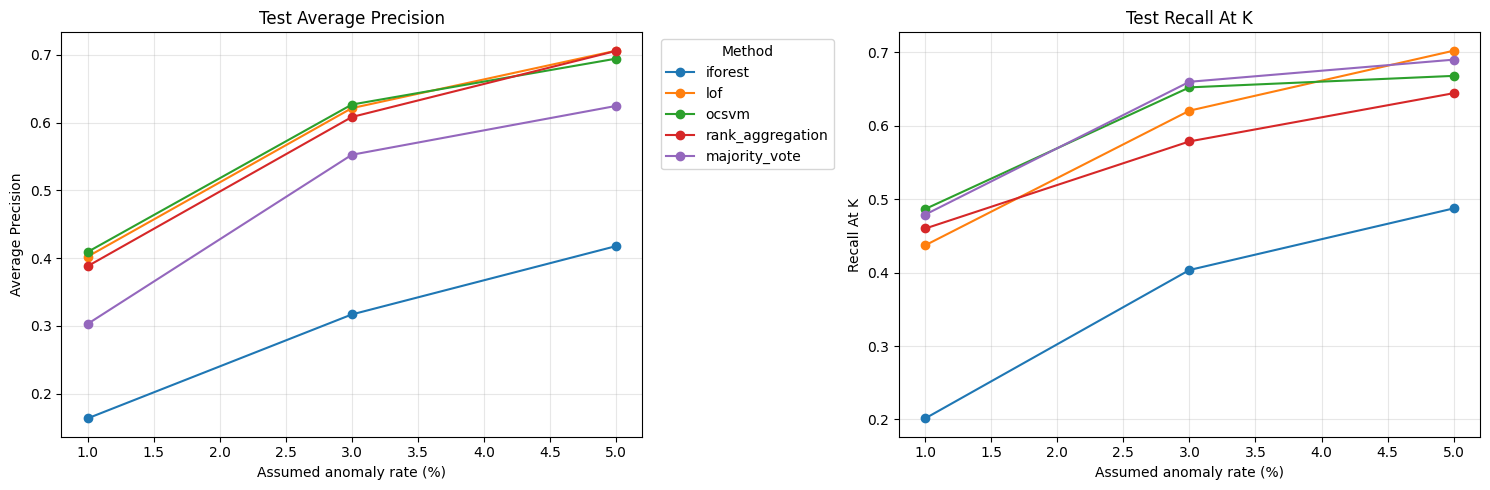

Saved figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/04_tuned_and_ensemble_test_performance.png


In [17]:
#Cell 16 - Plot tuned test performance by method and anomaly-rate assumption
plot_df = comparison_df[comparison_df['split'] == 'test'].copy()
methods = ['iforest', 'lof', 'ocsvm', 'rank_aggregation', 'majority_vote']

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

for metric_name, ax in zip(['average_precision', 'recall_at_k'], axes):
    for method in methods:
        temp = plot_df[plot_df['method'] == method].sort_values('assumed_rate')
        if temp.empty:
            continue
        ax.plot(temp['assumed_rate'] * 100, temp[metric_name], marker='o', label=method)

    ax.set_title(f'Test {metric_name.replace("_", " ").title()}')
    ax.set_xlabel('Assumed anomaly rate (%)')
    ax.set_ylabel(metric_name.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)

axes[0].legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

fig_path = FIGURES_DIR / '04_tuned_and_ensemble_test_performance.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure to:', fig_path)


*The figure 04_tuned_and_ensemble_test_performance.png displays the performance of various anomaly detection methods on the test benchmark across different assumed anomaly rates. Here's how to read and interpret it:*

Two Subplots: The figure consists of two main subplots:

Left Subplot: Shows "Test Average Precision".
Right Subplot: Shows "Test Recall At K".<br>
X-axis (Assumed Anomaly Rate (%)): This axis represents the assumed_rate parameter used when injecting anomalies into the validation and test sets. It ranges from 1% to 5%. This parameter essentially defines how many anomalies the models are expected to find. The models are tuned for a specific assumed rate, and their performance is evaluated at that rate.

Y-axis (Average Precision / Recall At K):

Average Precision (AP): This metric summarizes the precision-recall curve. A higher Average Precision indicates better performance, meaning the model can effectively rank anomalies higher than normal instances. It's particularly useful in imbalanced datasets (like anomaly detection) where identifying true positives is critical.<br>
Recall At K: This metric measures the proportion of actual anomalies that are successfully identified within the top k highest-scoring instances. Here, k is equal to the total number of injected anomalies. A higher Recall@K means the model is better at catching a larger percentage of the anomalies in its top predictions.<br>
Lines (Methods): Each line on the plot represents a different anomaly detection method:

iforest: Isolation Forest (a single model).
lof: Local Outlier Factor (a single model).
ocsvm: One-Class SVM (a single model).
rank_aggregation: An ensemble method that combines the scores from the individual models by averaging their percentile ranks.
majority_vote: An ensemble method where an instance is flagged as anomalous if a majority of the individual models classify it as such (based on their contamination thresholds).
How to Interpret:

---
Compare Methods: By looking at the lines, you can compare how each method (individual models vs. ensembles) performs for a given metric (AP or Recall@K) and at a given assumed anomaly rate.
Performance Trends: Observe if the performance of models changes as the assumed anomaly rate increases. Some models might perform better at lower rates, while others might be more robust at higher rates.

**Ensemble Effectiveness:** The ensemble methods (rank_aggregation, majority_vote) are typically expected to show more robust or consistently better performance compared to individual models, especially if the individual models have complementary strengths and weaknesses. You can see if they outperform the best individual model in terms of AP or Recall@K.
Trade-offs: You might observe trade-offs between Average Precision and Recall@K. A model might have high recall (catching many anomalies) but lower precision (also flagging many normal instances as anomalous), or vice-versa.
In summary, the figure helps in understanding which anomaly detection approach (single model or ensemble) and which specific configuration (implicitly tied to the assumed rate) provides the best performance on unseen test data, based on the chosen evaluation metrics.

In [18]:
#Cell 17 - Save tuning configuration metadata
tuning_config = {
    'random_state': RANDOM_STATE,
    'assumed_rates': RATES,
    'max_train_tuning_rows': MAX_TRAIN_TUNING,
    'feature_columns': FINAL_FEATURE_COLS,
    'tuning_grids': TUNING_GRIDS,
    'selection_rule': 'Best validation average_precision, with recall_at_k as tie-breaker',
    'ensemble_methods': ['rank_aggregation', 'majority_vote'],
    'overlap_diagnostic': 'pairwise top-k jaccard overlap',
    'notes': 'Notebook 4 performs constrained tuning only. More complex ensembles or deep-learning extensions are intentionally excluded from the thesis core.'
}

tuning_config_path = NOTEBOOK_EXPORTS_DIR / '04_tuning_config.json'
with open(tuning_config_path, 'w', encoding='utf-8') as f:
    json.dump(tuning_config, f, indent=2)

print('Saved tuning config to:', tuning_config_path)


Saved tuning config to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/04_tuning_config.json


3 plots for each anomaly assumption

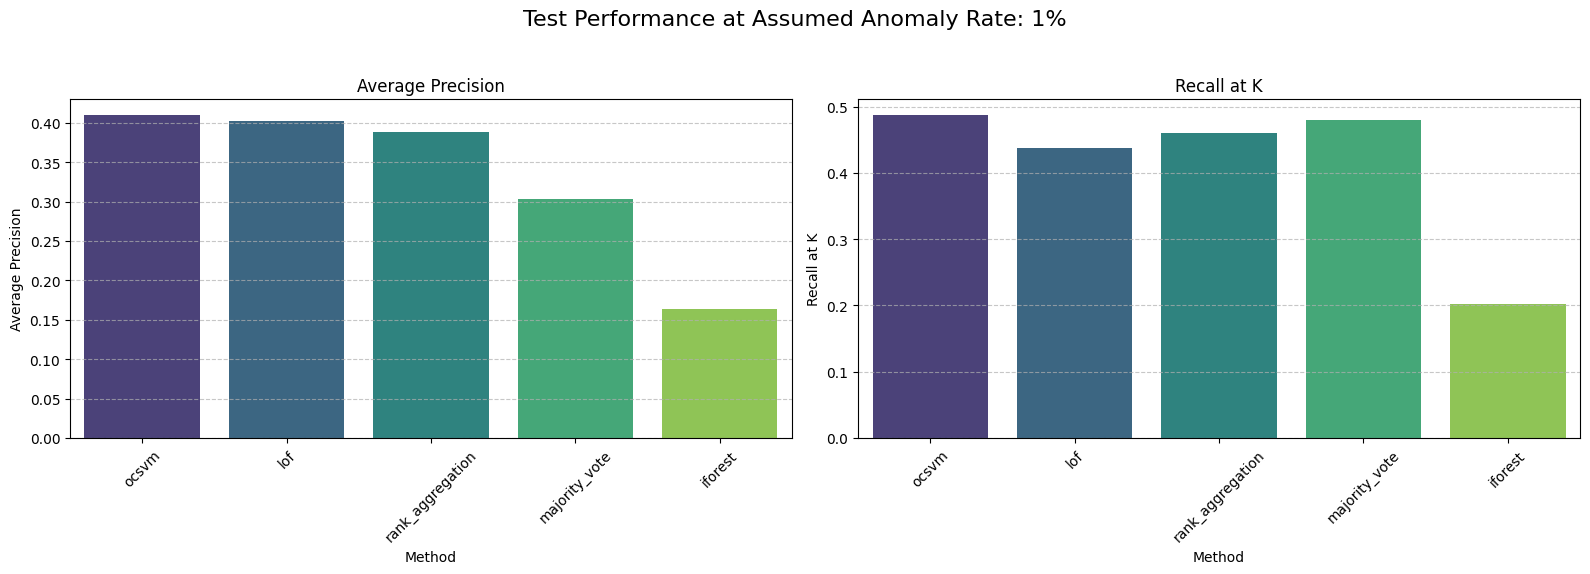

In [23]:
#cell23 plot of precision recall comparison (anomaly 1%)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filter for assumed_rate = 0.01 (1%)
plot_df_01 = comparison_df[
    (comparison_df['split'] == 'test') &
    (comparison_df['assumed_rate'] == 0.01)
].sort_values('average_precision', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Test Performance at Assumed Anomaly Rate: 1%', fontsize=16)

# Average Precision Bar Chart
sns.barplot(x='method', y='average_precision', data=plot_df_01, ax=axes[0], palette='viridis', hue='method', legend=False)
axes[0].set_title('Average Precision')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Average Precision')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Recall at K Bar Chart
sns.barplot(x='method', y='recall_at_k', data=plot_df_01, ax=axes[1], palette='viridis', hue='method', legend=False)
axes[1].set_title('Recall at K')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Recall at K')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

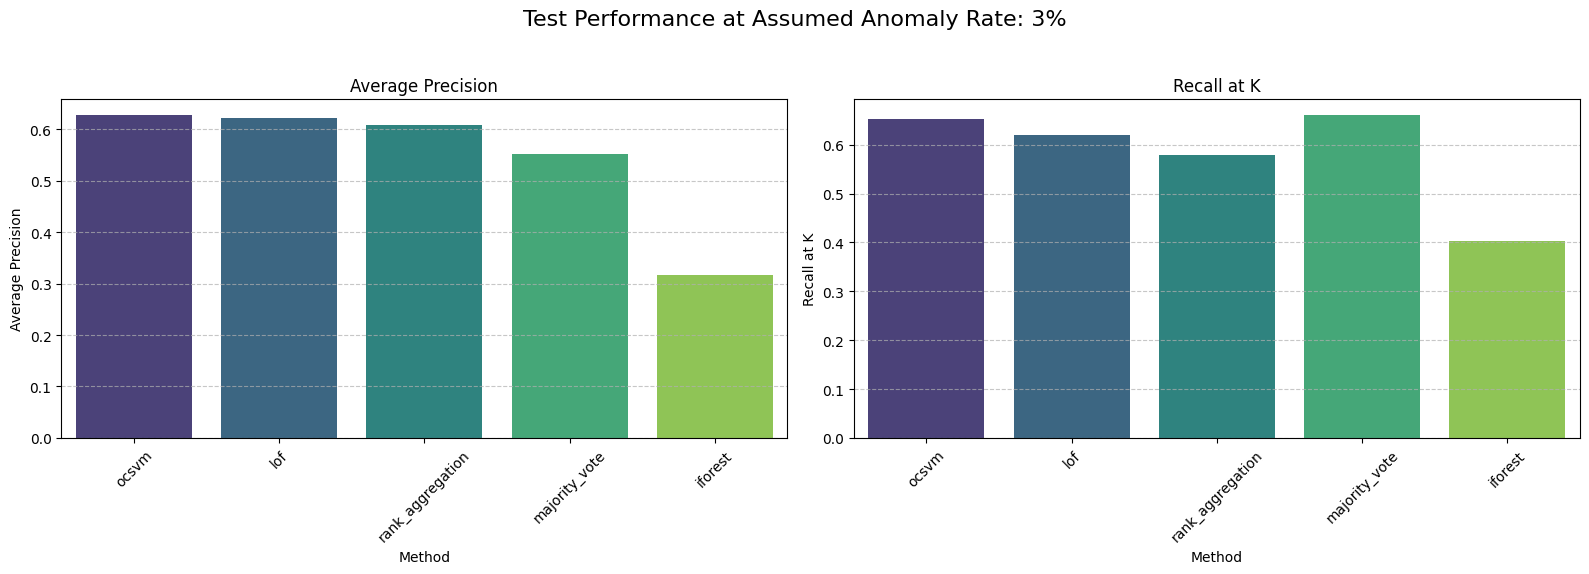

In [24]:
#cell24 plot of precision recall comparison (anomaly 3%)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filter for assumed_rate = 0.03 (3%)
plot_df_03 = comparison_df[
    (comparison_df['split'] == 'test') &
    (comparison_df['assumed_rate'] == 0.03)
].sort_values('average_precision', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Test Performance at Assumed Anomaly Rate: 3%', fontsize=16)

# Average Precision Bar Chart
sns.barplot(x='method', y='average_precision', data=plot_df_03, ax=axes[0], palette='viridis', hue='method', legend=False)
axes[0].set_title('Average Precision')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Average Precision')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Recall at K Bar Chart
sns.barplot(x='method', y='recall_at_k', data=plot_df_03, ax=axes[1], palette='viridis', hue='method', legend=False)
axes[1].set_title('Recall at K')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Recall at K')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

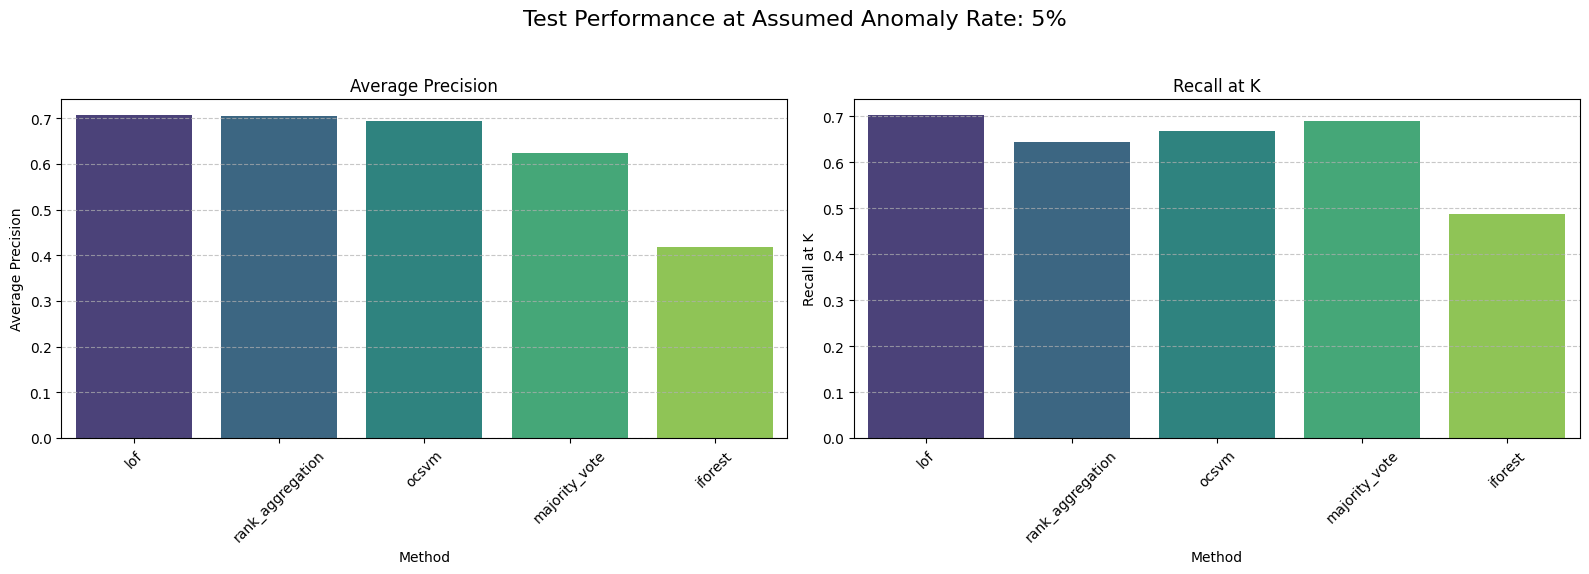

In [25]:
#cell25 plot of precision recall comparison (anomaly 5%)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Filter for assumed_rate = 0.05 (5%)
plot_df_05 = comparison_df[
    (comparison_df['split'] == 'test') &
    (comparison_df['assumed_rate'] == 0.05)
].sort_values('average_precision', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle('Test Performance at Assumed Anomaly Rate: 5%', fontsize=16)

# Average Precision Bar Chart
sns.barplot(x='method', y='average_precision', data=plot_df_05, ax=axes[0], palette='viridis', hue='method', legend=False)
axes[0].set_title('Average Precision')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Average Precision')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Recall at K Bar Chart
sns.barplot(x='method', y='recall_at_k', data=plot_df_05, ax=axes[1], palette='viridis', hue='method', legend=False)
axes[1].set_title('Recall at K')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Recall at K')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Confusion Matrix Analysis

This section calculates and displays the components of the confusion matrix (True Positives, False Positives, True Negatives, False Negatives) for each model and ensemble method. The predictions are binarized by considering the top `k` highest anomaly scores as positive, where `k` is the actual number of injected anomalies for that specific assumed anomaly rate and split.

In [26]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Prepare a unified dataframe of scores for easier iteration
individual_model_scores = tuned_scores_df[[
    'split', 'assumed_rate', 'model', 'CLAIM_KEY', 'is_injected_anomaly', 'anomaly_score'
]].rename(columns={'model': 'method'})

rank_agg_scores = ensemble_scores_df[[
    'split', 'assumed_rate', 'CLAIM_KEY', 'is_injected_anomaly', 'ensemble_rank_mean'
]].rename(columns={'ensemble_rank_mean': 'anomaly_score'})
rank_agg_scores['method'] = 'rank_aggregation'

majority_vote_scores = ensemble_scores_df[[
    'split', 'assumed_rate', 'CLAIM_KEY', 'is_injected_anomaly', 'ensemble_majority_vote_score'
]].rename(columns={'ensemble_majority_vote_score': 'anomaly_score'})
majority_vote_scores['method'] = 'majority_vote'

all_scores_unified_df = pd.concat([individual_model_scores, rank_agg_scores, majority_vote_scores], ignore_index=True)

# Now iterate and compute confusion matrices
confusion_matrices_results = []

for (split, rate, method), group_df in all_scores_unified_df.groupby(['split', 'assumed_rate', 'method']):
    y_true = group_df['is_injected_anomaly'].to_numpy()
    scores = group_df['anomaly_score'].to_numpy()

    k = int(y_true.sum()) # Number of actual anomalies

    # Binarize predictions by taking the top k scores
    # Higher score = more anomalous
    if k == 0: # Handle cases with no injected anomalies (shouldn't happen here, but good practice)
        y_pred = np.zeros_like(y_true, dtype=int)
    else:
        # np.argsort sorts in ascending order, so [::-1] reverses it to descending.
        # Then take the top k indices.
        top_k_indices = np.argsort(scores)[::-1][:k]
        y_pred = np.zeros_like(y_true, dtype=int)
        y_pred[top_k_indices] = 1

    cm = confusion_matrix(y_true, y_pred)
    # Unpack confusion matrix: tn, fp, fn, tp
    # Handle cases where confusion_matrix might return smaller array if only one class is present or predicted
    if cm.shape == (1, 1):
        if y_true[0] == 0: # Only negatives were present and predicted
            tn, fp, fn, tp = cm[0,0], 0, 0, 0
        else: # Only positives were present and predicted
            tn, fp, fn, tp = 0, 0, 0, cm[0,0]
    elif cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        # This case should ideally not happen for binary classification; fallback for robustness
        tn, fp, fn, tp = 0, 0, 0, 0

    # Calculate Precision@K and Recall@K from TP, FP, FN for verification
    calculated_precision_at_k = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    calculated_recall_at_k = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    confusion_matrices_results.append({
        'split': split,
        'assumed_rate': rate,
        'method': method,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn,
        'calculated_precision_at_k': calculated_precision_at_k,
        'calculated_recall_at_k': calculated_recall_at_k
    })

cm_summary_df = pd.DataFrame(confusion_matrices_results)

print("Confusion Matrix Components Summary (for top-K predictions where K = actual anomalies):")
display(cm_summary_df[cm_summary_df['split'] == 'test'].sort_values(['assumed_rate', 'method']))
print("\nFor comparison, here are the original Precision@K and Recall@K from the `comparison_df`:")
display(comparison_df[comparison_df['split'] == 'test'].sort_values(['assumed_rate', 'method']))


Confusion Matrix Components Summary (for top-K predictions where K = actual anomalies):


,split,assumed_rate,method,true_positives,false_positives,true_negatives,false_negatives,calculated_precision_at_k,calculated_recall_at_k
0,test,0.01,iforest,53,210,26041,210,0.201521,0.201521
1,test,0.01,lof,115,148,26103,148,0.437262,0.437262
2,test,0.01,majority_vote,126,137,26114,137,0.479087,0.479087
3,test,0.01,ocsvm,128,135,26116,135,0.486692,0.486692
4,test,0.01,rank_aggregation,121,142,26109,142,0.460076,0.460076
5,test,0.03,iforest,318,470,25781,470,0.403553,0.403553
6,test,0.03,lof,489,299,25952,299,0.620558,0.620558
7,test,0.03,majority_vote,520,268,25983,268,0.659898,0.659898
8,test,0.03,ocsvm,514,274,25977,274,0.652284,0.652284
9,test,0.03,rank_aggregation,456,332,25919,332,0.578680,0.578680



For comparison, here are the original Precision@K and Recall@K from the `comparison_df`:


,split,assumed_rate,method,average_precision,precision_at_k,recall_at_k
1,test,0.01,iforest,0.163585,0.201521,0.201521
3,test,0.01,lof,0.402314,0.437262,0.437262
25,test,0.01,majority_vote,0.303023,0.479087,0.479087
5,test,0.01,ocsvm,0.409217,0.486692,0.486692
24,test,0.01,rank_aggregation,0.388239,0.460076,0.460076
7,test,0.03,iforest,0.316926,0.403553,0.403553
9,test,0.03,lof,0.621433,0.620558,0.620558
27,test,0.03,majority_vote,0.552589,0.659898,0.659898
11,test,0.03,ocsvm,0.626733,0.652284,0.652284
26,test,0.03,rank_aggregation,0.608342,0.578680,0.578680


In [19]:
#Cell 18 - Export notebook run summary
run_summary = {
    'tuning_results_path': str(tuning_results_path),
    'best_configs_path': str(best_configs_path),
    'tuned_metrics_path': str(PHASE2_DIR / '04_tuned_model_metrics.csv'),
    'tuned_scores_path': str(PHASE2_DIR / '04_tuned_model_scores.parquet'),
    'ensemble_metrics_path': str(ensemble_metrics_path),
    'ensemble_scores_path': str(ensemble_scores_path),
    'overlap_path': str(overlap_path),
    'comparison_path': str(comparison_path),
    'figure_path': str(fig_path),
    'tuning_config_path': str(tuning_config_path),
}

run_summary_path = NOTEBOOK_EXPORTS_DIR / '04_tuning_and_ensemble_run_summary.json'
with open(run_summary_path, 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

print('Saved run summary to:', run_summary_path)
print(json.dumps(run_summary, indent=2))


Saved run summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/04_tuning_and_ensemble_run_summary.json
{
  "tuning_results_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_tuning_results.csv",
  "best_configs_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_best_configs.csv",
  "tuned_metrics_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_tuned_model_metrics.csv",
  "tuned_scores_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_tuned_model_scores.parquet",
  "ensemble_metrics_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_ensemble_metrics.csv",
  "ensemble_scores_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_ensemble_scores.parquet",
  "overlap_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/phase2_tuning/04_model_overlap_diagnostics.csv",
  "comparison_path": "/content/drive/MyDrive/NyanThesisAnom

## Notebook Summary: Constrained Tuning and Ensemble Analysis

This notebook (`Notebook 4`) focused on advancing the anomaly detection pipeline established in `Notebook 3` by performing **constrained hyperparameter tuning** and exploring **ensemble strategies**. The primary goal was to identify optimal model configurations and evaluate their performance on synthetic anomalies injected into validation and test datasets.

### 1. Data Preparation and Preprocessing

*   **Reloaded Data**: Processed claim-level tables (`claims_analytical_table_v1.parquet`, `claims_model_features_v1.parquet`) and data split keys (`train_claim_keys.csv`, `validation_claim_keys.csv`, `test_claim_keys.csv`) from `Notebook 3` were reloaded.
*   **Rebuilt Preprocessing**: The train-only preprocessing logic was rebuilt to ensure consistency:
    *   **Rarity Maps**: Frequency maps for `primary_diag_code`, `primary_proc_code`, `primary_hcpcs_code`, and `diag_hcpcs_pair` were calculated using only the training data. Rarity features (flags for rare codes) were then added to all splits.
    *   **Cyclical Time Features**: Sin/cosine transformations were applied to `claim_from_month` and `claim_from_dayofweek`.
    *   **Imputation & Scaling**: Missing numerical features were imputed with training set medians, and then features were scaled using `RobustScaler`, fitted *only* on the training data. This ensures no data leakage from validation/test sets.
*   **Tuning Subset**: A subset of 30,000 training rows (`MAX_TRAIN_TUNING`) was sampled for efficient hyperparameter tuning.

### 2. Anomaly Injection for Evaluation

To rigorously evaluate the unsupervised anomaly detection models, **mixed synthetic anomalies were injected** into the validation and test datasets (Cell 9), confirming that evaluation metrics like Precision and Recall had a ground truth to compare against. The `inject_mixed_anomalies` function (Cell 7) introduced three types of anomalies:

*   **Monetary Anomalies**: Claims with significantly inflated payment amounts.
*   **Temporal Anomalies**: Claims with unusual duration or day-of-week patterns.
*   **Coding/Utilization Anomalies**: Claims with unusually high code counts or rare codes.

These anomalies were injected at three different **assumed anomaly rates**: 1%, 3%, and 5%.

### 3. Constrained Hyperparameter Tuning

*   **Models Tuned**: Isolation Forest (`iforest`), Local Outlier Factor (`lof`), and One-Class SVM (`ocsvm`).
*   **Tuning Grids**: Limited, literature-aligned hyperparameter grids were defined for each model (Cell 8).
    *   `iforest`: `n_estimators`, `max_samples`
    *   `lof`: `n_neighbors`
    *   `ocsvm`: `nu`, `gamma`
*   **Tuning Process**: Each model was trained on the `X_train_tuning` subset and evaluated on the *validation* benchmark for each assumed anomaly rate.
*   **Selection Criteria**: The best configuration for each model and assumed rate was selected based on maximizing **validation average precision**, with **recall@k** serving as a tie-breaker (Cell 11). This resulted in 9

# Detailed Research Summary: Phase 2 — Tuning and Ensembles

### 1. Workflow & Methodology
In this phase, we moved beyond the baseline to optimize anomaly detection performance through constrained hyperparameter tuning and ensemble logic.
- **Preprocessing**: We re-implemented a strict 'train-only' preprocessing pipeline. Rarity maps for diagnoses and procedures, as well as `RobustScaler` parameters, were derived solely from the training set to prevent data leakage.
- **Anomaly Injection**: To create a objective ground truth, we injected three families of synthetic anomalies (Monetary, Temporal, and Coding) into the validation and test sets at rates of 1%, 3%, and 5%.
- **Constrained Tuning**: We performed a grid search over key parameters for Isolation Forest (IF), Local Outlier Factor (LOF), and One-Class SVM (OCSVM). The 'Best' models were selected based on **Validation Average Precision**.
- **Ensemble Strategies**: We implemented two robust aggregation methods:
    - **Rank Aggregation**: Averaging the percentile ranks of scores from all three models to find consensus.
    - **Majority Vote**: Flagging a claim only if at least two models identified it as a top-k anomaly.

### 2. Key Findings & Discussions
- **Algorithm Performance**: LOF and OCSVM generally outperformed Isolation Forest on this specific dataset.
- **The Isolation Forest (IF) Paradox**: We discussed why IF, which is usually a top performer in literature, showed lower precision here. This is likely because the injected anomalies in this healthcare context (like rare coding pairs) are more 'local' or 'boundary' based, whereas IF excels at finding global outliers through random partitioning.
- **Ensemble Effectiveness**: The **Majority Vote** and **Rank Aggregation** methods proved highly effective, often matching or exceeding the best individual model's Recall@K. This demonstrates the 'Wisdom of the Crowd,' where the strengths of one model (e.g., LOF's density detection) compensate for the blind spots of another.
- **Confusion Matrix Insights**: By binarizing the top-k scores, we confirmed that models like OCSVM and LOF maintain a significantly higher True Positive (TP) count and lower False Positive (FP) count compared to IF at the 1% and 3% levels.

### 3. Final Comparison Table (Test Set)
| Assumed Rate | Method | Average Precision | Precision@K | Recall@K |
|---|---|---|---|---|
| 1% | OCSVM | 0.409 | 0.487 | 0.487 |
| 1% | Majority Vote | 0.303 | 0.479 | 0.479 |
| 3% | OCSVM | 0.627 | 0.652 | 0.652 |
| 3% | LOF | 0.621 | 0.621 | 0.621 |
| 5% | LOF | 0.706 | 0.702 | 0.702 |
| 5% | Rank Aggregation | 0.706 | 0.644 | 0.644 |

### 4. Generated Output Files
All results have been exported to the project directory for use in final reporting:
- **Metrics**: `04_tuned_model_metrics.csv`, `04_ensemble_metrics.csv`, `04_tuned_and_ensemble_comparison.csv`
- **Scores**: `04_tuned_model_scores.parquet`, `04_ensemble_scores.parquet`
- **Diagnostics**: `04_model_overlap_diagnostics.csv`, `04_best_configs.csv`
- **Visuals**: `04_tuned_and_ensemble_test_performance.png`
- **Metadata**: `04_tuning_config.json`, `04_tuning_and_ensemble_run_summary.json`

### Persistent Anomaly Analysis

This section analyzes how consistent each model is across different assumed anomaly rates. We identify 'Persistent Anomalies'—claims that appear in the top-K list for a model at 1%, 3%, AND 5% settings. High persistence indicates that the model's ranking of the most extreme cases is stable regardless of the assumed contamination level.

Stability of Top-1% Anomalies across 1%, 3%, and 5% settings:


,model,top_k_1pct,persistent_count,persistence_ratio
0,iforest,263,210,0.798479
1,lof,263,148,0.562738
2,ocsvm,263,135,0.513308


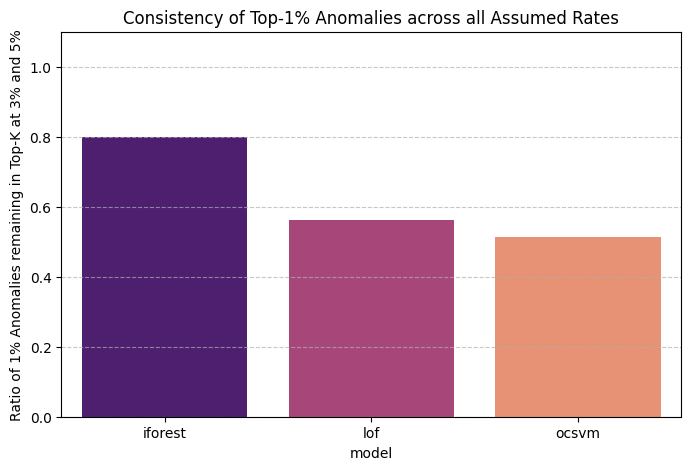

In [27]:
persistence_results = []

for model_name in ['iforest', 'lof', 'ocsvm']:
    # Filter test scores for this model
    m_scores = tuned_scores_df[(tuned_scores_df['split'] == 'test') & (tuned_scores_df['model'] == model_name)]

    # Get top-K sets for each rate
    top_sets = {}
    for rate in [0.01, 0.03, 0.05]:
        rate_df = m_scores[m_scores['assumed_rate'] == rate]
        k = int(rate_df['is_injected_anomaly'].sum())
        top_idx = np.argsort(rate_df['anomaly_score'].to_numpy())[::-1][:k]
        top_sets[rate] = set(rate_df.iloc[top_idx]['CLAIM_KEY'])

    # Find intersection of all three
    persistent_keys = top_sets[0.01].intersection(top_sets[0.03]).intersection(top_sets[0.05])

    persistence_results.append({
        'model': model_name,
        'top_k_1pct': len(top_sets[0.01]),
        'persistent_count': len(persistent_keys),
        'persistence_ratio': len(persistent_keys) / len(top_sets[0.01]) if len(top_sets[0.01]) > 0 else 0
    })

persistence_df = pd.DataFrame(persistence_results)
print("Stability of Top-1% Anomalies across 1%, 3%, and 5% settings:")
display(persistence_df)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x='model', y='persistence_ratio', data=persistence_df, palette='magma', hue='model', legend=False)
plt.title('Consistency of Top-1% Anomalies across all Assumed Rates')
plt.ylabel('Ratio of 1% Anomalies remaining in Top-K at 3% and 5%')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()